# Type C — Futures Funded-Continuation Surplus Hedge

**Asset class:** Futures (ES, NQ, etc.)  
**Hedge Type:** Hedge through eval, get funded, keep hedging, and deliberately **oversize** the funded hedge so that a failure event produces **surplus profit**.

**Goal:** Even when the prop side loses, that loss becomes a monetisable outcome.

## EV Formula

$$\text{EV}_C = \text{funded withdrawals} + \text{surplus on failure} - \text{all hedge drag}$$

## Hedge Sizing

**Type B (recovery only):** $S = \dfrac{L}{DD}$

**Type C (recovery + surplus):** $S = \dfrac{L + P}{DD}$

Where $P$ = desired surplus profit on failure.

## Futures-Specific Constraints

| Constraint | Impact on Type C |
|-----------|------------------|
| **Trailing DD** | Higher challenge cost → bigger base stack → even bigger oversized hedge |
| **Payout cap** | Limits withdrawal per cycle but surplus on failure is uncapped |
| **Activation fee** | Adds to the stack that the oversized hedge must cover |
| **Consistency (funded)** | Constrains funded-phase hedge operation |

## Key Question

> "Can I build the futures hedge so that when the prop side fails, I pocket a surplus beyond just cost recovery?"

---

**Reference:** [futures-hedge-model.md](../../directives/Business/futures-hedge-model.md)

## 0 — Setup & Imports

In [1]:
import sys, os, json, math, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

WS_ROOT = os.environ.get(
    "WORKSPACE_ROOT",
    r"C:\Users\sossi\Desktop\Business\Orchestrator Hedge Edge"
)
if WS_ROOT not in sys.path:
    sys.path.insert(0, WS_ROOT)

STRATEGY_ROOT = os.path.join(WS_ROOT, "Business", "STRATEGY")
DATA_DIR = os.path.join(STRATEGY_ROOT, "resources", "PropFirmData")

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

# ── Tuneable assumptions ──
FUNDED_TARGET_PCT   = 0.06
SPREAD_PER_CONTRACT = 5.00
CONSISTENCY_THRESHOLD = 0.20

# ── Type C funded-phase assumptions ──
FUNDED_WITHDRAWAL_PCT = 0.04
FUNDED_CYCLES = 6
FUNDED_SURVIVAL_RATE = 0.80
FUNDED_HEDGE_DRAG_PCT = 0.015
SURPLUS_TARGET_PCT = 0.02  # desired surplus = 2% of account on failure

print("Type C Futures notebook ready.")
print(f"Challenge: funded_target={FUNDED_TARGET_PCT*100:.0f}%, spread=${SPREAD_PER_CONTRACT}/contract")
print(f"Funded: withdrawal={FUNDED_WITHDRAWAL_PCT*100:.1f}%/cycle, "
      f"survival={FUNDED_SURVIVAL_RATE*100:.0f}%/cycle, "
      f"drag={FUNDED_HEDGE_DRAG_PCT*100:.1f}%/cycle")
print(f"Surplus target: {SURPLUS_TARGET_PCT*100:.1f}% of account on failure")

Type C Futures notebook ready.
Challenge: funded_target=6%, spread=$5.0/contract
Funded: withdrawal=4.0%/cycle, survival=80%/cycle, drag=1.5%/cycle
Surplus target: 2.0% of account on failure


## 1 — Load & Normalise Futures Data

In [2]:
json_files = glob.glob(os.path.join(DATA_DIR, "propmatch_futures_*.json"))
if not json_files:
    raise FileNotFoundError("No futures data found.")

latest = max(json_files, key=os.path.getmtime)
print(f"Loading: {os.path.basename(latest)}")

with open(latest, 'r', encoding='utf-8') as f:
    raw = json.load(f)

challenges_raw = raw.get("challenges", raw if isinstance(raw, list) else [])
print(f"Loaded {len(challenges_raw)} raw futures challenges")


def parse_dollar(val):
    if isinstance(val, (int, float)): return float(val)
    if not val or val == '-' or str(val).lower() == 'none': return 0.0
    cleaned = re.sub(r'[^\d.]', '', str(val).replace(',', ''))
    return float(cleaned) if cleaned else 0.0

def parse_pct(val):
    if isinstance(val, (int, float)): return float(val) if val > 1 else val * 100
    if not val or val == '-' or str(val).lower() == 'none': return 0.0
    cleaned = re.sub(r'[^\d.]', '', str(val))
    return float(cleaned) if cleaned else 0.0

def parse_consistency(val):
    if not val or val == '-' or str(val).lower() == 'none': return 0.0
    cleaned = re.sub(r'[^\d.]', '', str(val))
    if cleaned:
        pct = float(cleaned)
        return pct / 100.0 if pct > 1 else pct
    return 0.0

def classify_dd_type(val):
    if not val: return "trailing"
    v = str(val).lower()
    if "trail" in v: return "trailing"
    if "static" in v or "balance" in v: return "static"
    return "trailing"

def normalise_challenge(c):
    fee = parse_dollar(c.get('fee_assumed') or c.get('fee_original') or c.get('fee_discounted') or 0)
    activation = parse_dollar(c.get('activation_fee', 0))
    profit_target = parse_dollar(c.get('profit_target', 0))
    if profit_target == 0 and c.get('profit_targets'):
        targets = c['profit_targets']
        if isinstance(targets, list) and targets:
            profit_target = sum(parse_dollar(t) for t in targets)
    max_loss = parse_dollar(c.get('max_loss') or c.get('max_drawdown_pct', 0))
    account_size = parse_dollar(c.get('account_size', 0))
    split = parse_pct(c.get('profit_split_pct') or c.get('profit_split', 80)) / 100.0
    payout_cap = parse_dollar(c.get('max_payout_amount', 0))
    min_threshold = parse_dollar(c.get('min_payout_threshold', 0))
    dd_type = classify_dd_type(c.get('max_loss_type', ''))
    cr = c.get('consistency_rule', {})
    if isinstance(cr, dict):
        consistency_eval = parse_consistency(cr.get('eval', 'None'))
        consistency_funded = parse_consistency(cr.get('funded', 'None'))
    else:
        consistency_eval = parse_consistency(c.get('consistency_rule_eval', 'None'))
        consistency_funded = parse_consistency(c.get('consistency_rule_funded', 'None'))
    mc = c.get('max_contract_size', c.get('max_contracts_minis', 0))
    if isinstance(mc, dict): minis = int(mc.get('minis', 0) or 0)
    elif isinstance(mc, str): nums = re.findall(r'\d+', mc); minis = int(nums[0]) if nums else 0
    else: minis = int(mc) if mc else 0
    return {
        'firm': c.get('firm', 'Unknown'), 'account_size': account_size,
        'steps': int(c.get('steps', 1) if c.get('steps') else 1),
        'fee': fee, 'activation_fee': activation,
        'profit_target': profit_target, 'max_loss': max_loss,
        'dd_type': dd_type, 'profit_split': split,
        'max_contracts_minis': minis, 'payout_cap': payout_cap,
        'min_payout_threshold': min_threshold,
        'consistency_eval': consistency_eval,
        'consistency_funded': consistency_funded,
    }

parsed = [normalise_challenge(c) for c in challenges_raw]
print(f"Parsed {len(parsed)} futures challenges")
print(f"Account sizes: {sorted(set(ch['account_size'] for ch in parsed))}")

Loading: propmatch_futures_20260324_231245.json
Loaded 76 raw futures challenges
Parsed 76 futures challenges
Account sizes: [25000.0, 50000.0, 75000.0, 100000.0, 150000.0, 200000.0, 300000.0]


## 2 — Type C Model: Challenge Phase + Surplus Continuation

### How Type C extends Type B

Type B sizes the funded hedge for **recovery only** ($S = L / DD$).  
Type C sizes for **recovery + surplus** ($S = (L + P) / DD$).

The oversized hedge means:
- More drag per cycle (bigger hedge = more loss when funded account profits)
- But failure produces surplus profit, not just stack recovery

### The tradeoff

| | Type B | Type C |
|---|---|---|
| Hedge sizing | $L / DD$ | $(L + P) / DD$ |
| Drag per cycle | Lower | Higher |
| Failure outcome | Recovers costs | Recovers costs + surplus |
| Capital required | Lower | Higher |

In [3]:
def compute_type_a_cost_futures(ch, funded_target_pct=FUNDED_TARGET_PCT,
                                spread_per_contract=SPREAD_PER_CONTRACT):
    S = ch['account_size']; fee = ch['fee']; act_fee = ch['activation_fee']
    target = ch['profit_target']; DD = ch['max_loss']
    split = ch['profit_split']; dd_type = ch['dd_type']
    minis = ch['max_contracts_minis'] or 1
    cap = ch['payout_cap']; threshold = ch['consistency_eval']; steps = ch['steps']
    if S <= 0 or DD <= 0 or target <= 0: return None

    min_days = math.ceil(1.0 / threshold) if threshold > 0 else 1
    N = max(min_days, 10)
    L = fee
    for step in range(steps):
        step_target = target / steps
        daily_move = step_target / N
        if dd_type == 'trailing':
            for _ in range(N):
                L += daily_move * L / DD + minis * spread_per_contract * 2
        else:
            L += target * L / DD + minis * spread_per_contract * 2 * N
    total_cost = L + act_fee
    return {
        'firm': ch['firm'], 'account_size': S, 'fee': round(fee, 2),
        'activation_fee': round(act_fee, 2), 'steps': steps,
        'dd_type': dd_type, 'dd_max': DD, 'split': split,
        'payout_cap': cap, 'minis': minis,
        'challenge_cost': round(total_cost, 2),
    }


def compute_type_bc_futures(ch,
                            funded_target_pct=FUNDED_TARGET_PCT,
                            spread_per_contract=SPREAD_PER_CONTRACT,
                            withdrawal_pct=FUNDED_WITHDRAWAL_PCT,
                            n_cycles=FUNDED_CYCLES,
                            survival_rate=FUNDED_SURVIVAL_RATE,
                            hedge_drag_pct=FUNDED_HEDGE_DRAG_PCT,
                            surplus_target_pct=0.0):
    """
    Unified Type B/C model for Futures.
    - surplus_target_pct = 0  → Type B (recovery only)
    - surplus_target_pct > 0  → Type C (recovery + surplus)
    """
    base = compute_type_a_cost_futures(ch, funded_target_pct, spread_per_contract)
    if base is None: return None
    S = base['account_size']; split = base['split']; DD = base['dd_max']
    L = base['challenge_cost']; cap = base['payout_cap']
    P = S * surplus_target_pct  # absolute surplus target

    total_withdrawals = 0.0; total_drag = 0.0; expected_surplus = 0.0
    cycle_details = []; cum_survival = 1.0

    for k in range(1, n_cycles + 1):
        prob_alive = cum_survival
        # Withdrawal (respect payout cap)
        raw_withdrawal = S * withdrawal_pct * split
        withdrawal = min(raw_withdrawal, cap) if cap > 0 else raw_withdrawal
        exp_withdrawal = withdrawal * prob_alive
        # Drag scaled by (L+P)/L
        base_drag = S * hedge_drag_pct
        drag_multiplier = (L + P) / L if L > 0 else 1.0
        drag = base_drag * drag_multiplier
        exp_drag = drag * prob_alive
        L_cycle_start = L; L += drag
        # Failure surplus
        prob_fail = prob_alive * (1 - survival_rate)
        exp_surplus = P * prob_fail
        # Capital
        hedge_size = (L + P) / DD if DD > 0 else 0
        margin = hedge_size / 100; buffer = hedge_size * DD * 1.5
        capital = margin + buffer

        total_withdrawals += exp_withdrawal
        total_drag += exp_drag
        expected_surplus += exp_surplus
        cycle_details.append({
            'cycle': k, 'prob_alive': round(prob_alive, 4),
            'insured_stack': round(L_cycle_start, 2),
            'surplus_target': round(P, 2),
            'hedge_total_cover': round(L_cycle_start + P, 2),
            'withdrawal': round(withdrawal, 2),
            'exp_withdrawal': round(exp_withdrawal, 2),
            'drag': round(drag, 2), 'exp_drag': round(exp_drag, 2),
            'prob_fail': round(prob_fail, 4),
            'exp_surplus': round(exp_surplus, 2),
            'capital': round(capital, 2),
        })
        cum_survival *= survival_rate

    # Type A comparison
    type_a_payout = S * funded_target_pct * split
    if cap > 0: type_a_payout = min(type_a_payout, cap)
    type_a_ev = type_a_payout - base['challenge_cost']
    ev = total_withdrawals + expected_surplus - total_drag
    max_capital = max(c['capital'] for c in cycle_details) if cycle_details else 0

    return {
        'firm': base['firm'], 'account_size': S, 'fee': base['fee'],
        'activation_fee': base['activation_fee'], 'steps': base['steps'],
        'dd_type': base['dd_type'], 'payout_cap': round(cap, 2),
        'challenge_cost': base['challenge_cost'],
        'surplus_target': round(P, 2),
        'type_a_ev': round(type_a_ev, 2),
        'total_withdrawals': round(total_withdrawals, 2),
        'total_drag': round(total_drag, 2),
        'expected_surplus': round(expected_surplus, 2),
        'ev': round(ev, 2),
        'ev_vs_type_a': round(ev - type_a_ev, 2),
        'capital_required': round(max_capital, 2),
        'capital_efficiency': round(ev / max_capital, 4) if max_capital > 0 else 0,
        'cycles': cycle_details,
    }


# Compute both Type B and C for comparison
results_b = [compute_type_bc_futures(ch, surplus_target_pct=0) for ch in parsed]
results_c = [compute_type_bc_futures(ch, surplus_target_pct=SURPLUS_TARGET_PCT) for ch in parsed]
results_b = [r for r in results_b if r is not None]
results_c = [r for r in results_c if r is not None]
df_b = pd.DataFrame(results_b)
df_c = pd.DataFrame(results_c)

print(f"✅ Type B — Positive EV: {(df_b['ev'] > 0).sum()}/{len(df_b)}, Avg: ${df_b['ev'].mean():,.2f}")
print(f"✅ Type C — Positive EV: {(df_c['ev'] > 0).sum()}/{len(df_c)}, Avg: ${df_c['ev'].mean():,.2f}")
print(f"📊 Surplus target: ${df_c['surplus_target'].min():,.0f}–${df_c['surplus_target'].max():,.0f}")
print(f"📊 Average Type C advantage over B: ${(df_c['ev'] - df_b['ev']).mean():,.2f}")

✅ Type B — Positive EV: 58/58, Avg: $4,398.51
✅ Type C — Positive EV: 56/58, Avg: $3,673.45
📊 Surplus target: $500–$6,000
📊 Average Type C advantage over B: $-725.06


## 3 — Type C Rankings (Top 30)

In [4]:
rank_cols = [
    'firm', 'account_size', 'dd_type', 'fee', 'activation_fee',
    'payout_cap', 'challenge_cost', 'surplus_target',
    'total_withdrawals', 'total_drag', 'expected_surplus',
    'ev', 'ev_vs_type_a', 'capital_required', 'capital_efficiency'
]

df_c.sort_values('ev', ascending=False)[rank_cols].head(30).style.format({
    'fee': '${:,.0f}', 'activation_fee': '${:,.0f}',
    'challenge_cost': '${:,.2f}', 'surplus_target': '${:,.0f}',
    'total_withdrawals': '${:,.2f}', 'total_drag': '${:,.2f}',
    'expected_surplus': '${:,.2f}', 'ev': '${:,.2f}',
    'ev_vs_type_a': '${:+,.2f}', 'capital_required': '${:,.0f}',
    'capital_efficiency': '{:.4f}', 'account_size': '${:,}',
    'payout_cap': '${:,.0f}',
}).bar(subset=['ev'], color='#5fba7d').bar(
    subset=['expected_surplus'], color='#ff9800'
).set_caption(
    f"Futures Type C Rankings — Top 30 (surplus={SURPLUS_TARGET_PCT*100:.1f}% of account)"
)

,firm,account_size,dd_type,fee,activation_fee,payout_cap,challenge_cost,surplus_target,total_withdrawals,total_drag,expected_surplus,ev,ev_vs_type_a,capital_required,capital_efficiency
42,My Funded Futures,"$150,000.0",trailing,$347,$0,"$100,000","$6,042.33","$3,000","$19,922.11","$10,831.38","$2,213.57","$11,304.30","$+9,246.63","$39,111",0.2890
47,Topstep,"$150,000.0",trailing,$149,$149,"$5,000","$4,965.37","$3,000","$18,446.40","$11,174.16","$2,213.57","$9,485.81","$+9,451.18","$38,092",0.2490
52,TradeDay,"$150,000.0",trailing,$300,$139,"$20,000","$6,828.26","$3,000","$17,708.54","$10,632.84","$2,213.57","$9,289.27","$+8,917.53","$39,933",0.2326
48,Take Profit Trader,"$150,000.0",trailing,$360,$130,$0,"$6,252.83","$3,000","$17,708.54","$10,774.65","$2,213.57","$9,147.46","$+8,200.29","$39,326",0.2326
53,The Trading Pit Futures,"$150,000.0",trailing,$289,$129,"$500,050","$5,812.21","$3,000","$17,708.54","$10,896.78","$2,213.57","$9,025.34","$+7,637.55","$38,882",0.2321
26,My Funded Futures,"$100,000.0",trailing,$267,$0,"$100,000","$4,249.06","$2,000","$13,281.41","$7,162.23","$1,475.71","$7,594.89","$+6,443.95","$26,301",0.2888
32,Topstep,"$100,000.0",trailing,$99,$149,"$5,000","$3,357.85","$2,000","$13,281.41","$7,432.12","$1,475.71","$7,325.00","$+5,682.85","$25,437",0.2880
50,AquaFutures,"$150,000.0",trailing,$285,$0,"$4,500","$3,608.56","$3,000","$16,601.76","$11,803.52","$2,213.57","$7,011.81","$+6,120.37","$37,094",0.1890
33,Take Profit Trader,"$100,000.0",trailing,$330,$130,$0,"$5,288.31","$2,000","$11,805.70","$6,936.23","$1,475.71","$6,345.17","$+6,833.48","$27,445",0.2312
54,Earn2Trade,"$150,000.0",trailing,$375,$139,"$4,000","$6,354.70","$3,000","$14,757.12","$10,748.19","$2,213.57","$6,222.50","$+8,577.20","$39,431",0.1578


## 4 — Three-Way Comparison: Type A vs B vs C

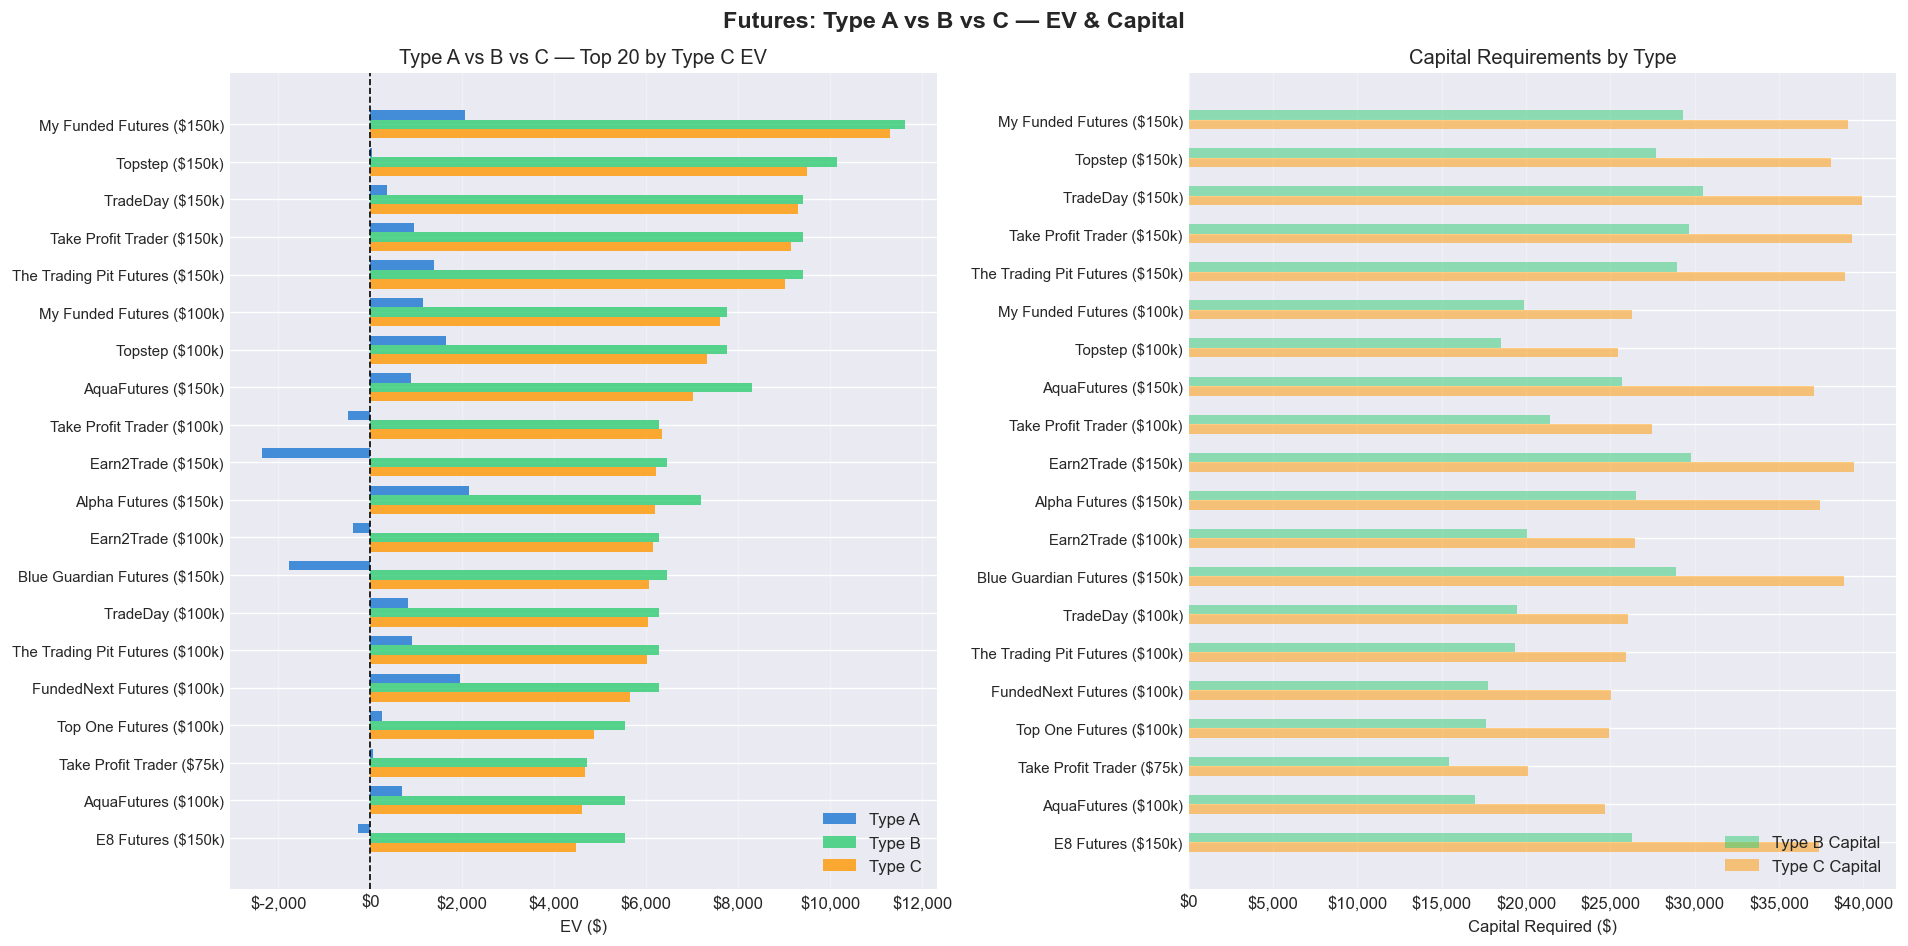

In [5]:
top20 = df_c.nlargest(20, 'ev').sort_values('ev', ascending=True).copy()
# Find matching Type B rows
b_lookup = {(r['firm'], r['account_size']): r['ev'] for r in results_b if r}
top20['type_b_ev'] = top20.apply(
    lambda r: b_lookup.get((r['firm'], r['account_size']), 0), axis=1
)
top20['label'] = top20.apply(
    lambda r: f"{r['firm']} (${r['account_size']/1000:.0f}k)", axis=1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

y = np.arange(len(top20))
h = 0.25

ax1.barh(y + h, top20['type_a_ev'], h, label='Type A', color='#1976d2', alpha=0.8)
ax1.barh(y, top20['type_b_ev'], h, label='Type B', color='#2ecc71', alpha=0.8)
ax1.barh(y - h, top20['ev'], h, label='Type C', color='#ff9800', alpha=0.8)
ax1.set_yticks(y)
ax1.set_yticklabels(top20['label'], fontsize=9)
ax1.axvline(x=0, color='black', linewidth=1, linestyle='--')
ax1.set_xlabel('EV ($)')
ax1.set_title('Type A vs B vs C — Top 20 by Type C EV')
ax1.legend(loc='lower right')
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(axis='x', alpha=0.3)

# Right: capital comparison
b_cap_lookup = {(r['firm'], r['account_size']): r['capital_required'] for r in results_b if r}
top20['cap_b'] = top20.apply(
    lambda r: b_cap_lookup.get((r['firm'], r['account_size']), 0), axis=1
)
ax2.barh(y + h/2, top20['cap_b'], h, label='Type B Capital', color='#2ecc71', alpha=0.5)
ax2.barh(y - h/2, top20['capital_required'], h, label='Type C Capital', color='#ff9800', alpha=0.5)
ax2.set_yticks(y)
ax2.set_yticklabels(top20['label'], fontsize=9)
ax2.set_xlabel('Capital Required ($)')
ax2.set_title('Capital Requirements by Type')
ax2.legend(loc='lower right')
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Futures: Type A vs B vs C — EV & Capital', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5 — Funded Phase Walkthrough (Single Challenge)

In [6]:
best_idx = df_c['ev'].idxmax()
best_c = results_c[best_idx]
best_b = results_b[best_idx]

print(f"Challenge: {best_c['firm']} — ${best_c['account_size']:,}")
print(f"Challenge cost: ${best_c['challenge_cost']:,.2f}")
print(f"Surplus target: ${best_c['surplus_target']:,.2f}")
print(f"Payout cap: ${best_c['payout_cap']:,.0f}")
print()
print(f"  Type A EV:  ${best_c['type_a_ev']:,.2f}")
print(f"  Type B EV:  ${best_b['ev']:,.2f}")
print(f"  Type C EV:  ${best_c['ev']:,.2f}")
print(f"  C vs A:     ${best_c['ev_vs_type_a']:+,.2f}")
print(f"  C vs B:     ${best_c['ev'] - best_b['ev']:+,.2f}")
print()

df_cyc = pd.DataFrame(best_c['cycles'])
df_cyc.style.format({
    'prob_alive': '{:.1%}', 'insured_stack': '${:,.2f}',
    'surplus_target': '${:,.0f}', 'hedge_total_cover': '${:,.2f}',
    'withdrawal': '${:,.2f}', 'exp_withdrawal': '${:,.2f}',
    'drag': '${:,.2f}', 'exp_drag': '${:,.2f}',
    'prob_fail': '{:.1%}', 'exp_surplus': '${:,.2f}',
    'capital': '${:,.0f}',
}).set_caption(f"Type C Cycle Detail — {best_c['firm']} ${best_c['account_size']:,}")

Challenge: My Funded Futures — $150,000.0
Challenge cost: $6,042.33
Surplus target: $3,000.00
Payout cap: $100,000

  Type A EV:  $2,057.67
  Type B EV:  $11,621.23
  Type C EV:  $11,304.30
  C vs A:     $+9,246.63
  C vs B:     $-316.93



,cycle,prob_alive,insured_stack,surplus_target,hedge_total_cover,withdrawal,exp_withdrawal,drag,exp_drag,prob_fail,exp_surplus,capital
0,1,100.0%,"$6,042.33","$3,000","$9,042.33","$5,400.00","$5,400.00","$3,367.12","$3,367.12",20.0%,$600.00,"$18,614"
1,2,80.0%,"$9,409.45","$3,000","$12,409.45","$5,400.00","$4,320.00","$2,967.36","$2,373.89",16.0%,$480.00,"$23,065"
2,3,64.0%,"$12,376.81","$3,000","$15,376.81","$5,400.00","$3,456.00","$2,795.37","$1,789.04",12.8%,$384.00,"$27,258"
3,4,51.2%,"$15,172.19","$3,000","$18,172.19","$5,400.00","$2,764.80","$2,694.89","$1,379.79",10.2%,$307.20,"$31,301"
4,5,41.0%,"$17,867.08","$3,000","$20,867.08","$5,400.00","$2,211.84","$2,627.79","$1,076.34",8.2%,$245.76,"$35,242"
5,6,32.8%,"$20,494.87","$3,000","$23,494.87","$5,400.00","$1,769.47","$2,579.35",$845.20,6.6%,$196.61,"$39,111"


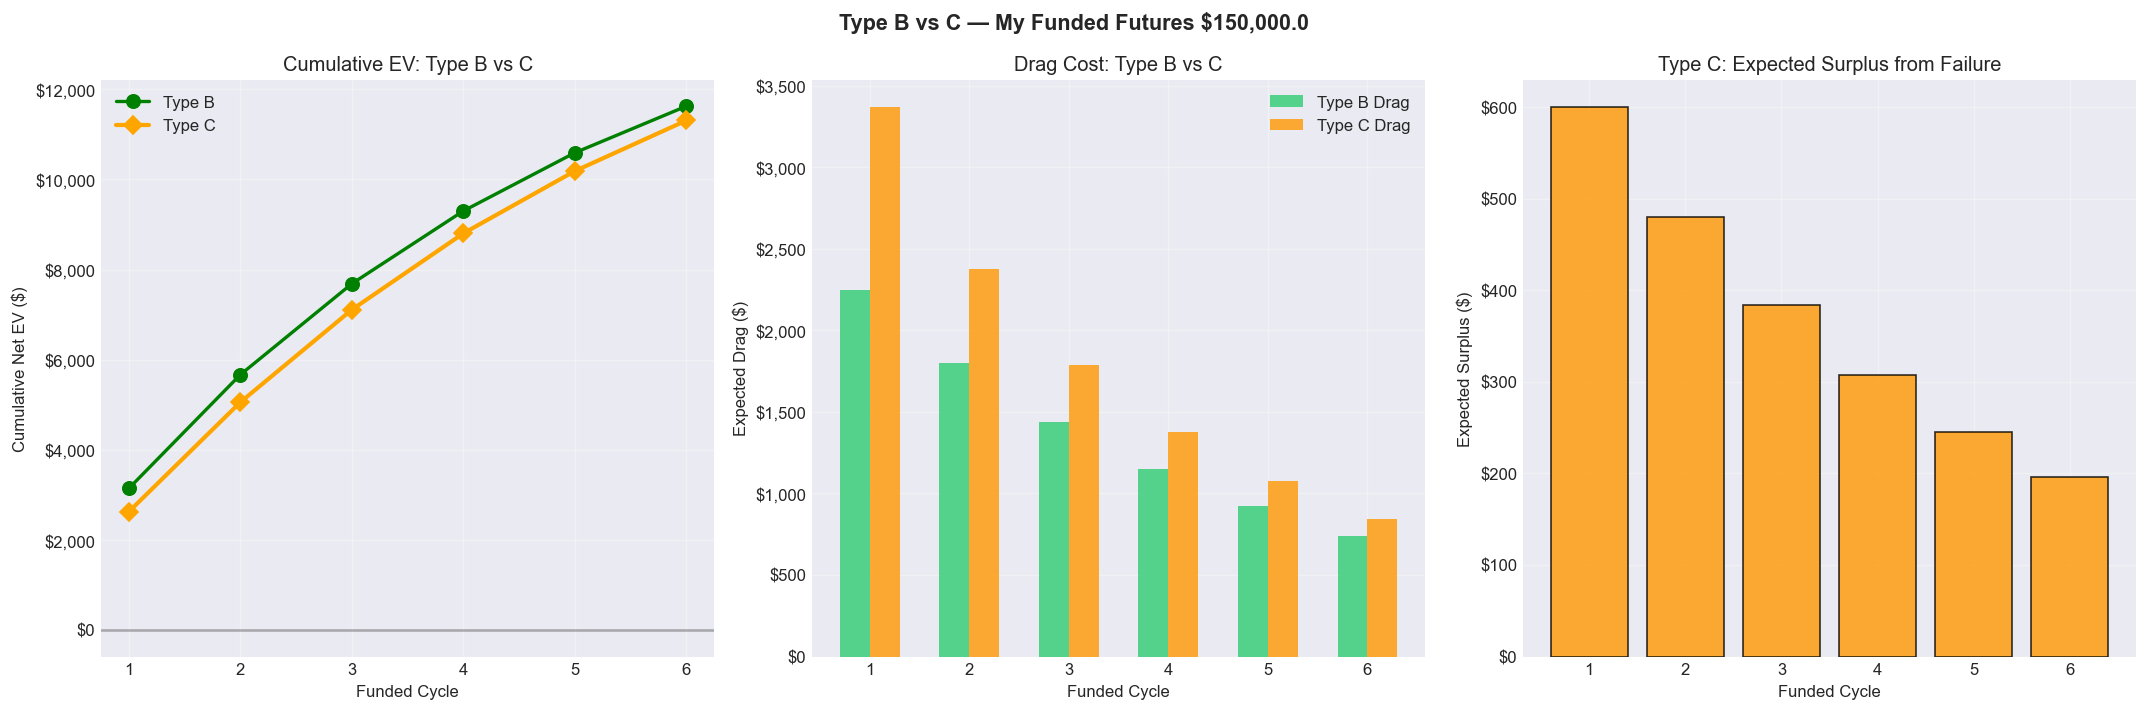

In [7]:
cyc_b = best_b['cycles']; cyc_c = best_c['cycles']
nums = [c['cycle'] for c in cyc_c]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Cumulative net
cum_net_b = np.cumsum([c['exp_withdrawal'] - c['exp_drag'] for c in cyc_b])
cum_net_c = np.cumsum([c['exp_withdrawal'] - c['exp_drag'] + c['exp_surplus'] for c in cyc_c])
axes[0].plot(nums, cum_net_b, 'g-o', linewidth=2, markersize=8, label='Type B')
axes[0].plot(nums, cum_net_c, 'orange', marker='D', linewidth=2.5, markersize=8, label='Type C')
axes[0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[0].set_xlabel('Funded Cycle'); axes[0].set_ylabel('Cumulative Net EV ($)')
axes[0].set_title('Cumulative EV: Type B vs C')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(alpha=0.3)

# Panel 2: Drag comparison
drag_b = [c['exp_drag'] for c in cyc_b]; drag_c = [c['exp_drag'] for c in cyc_c]
x = np.arange(len(nums))
axes[1].bar(x - 0.15, drag_b, 0.3, label='Type B Drag', color='#2ecc71', alpha=0.8)
axes[1].bar(x + 0.15, drag_c, 0.3, label='Type C Drag', color='#ff9800', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(nums)
axes[1].set_xlabel('Funded Cycle'); axes[1].set_ylabel('Expected Drag ($)')
axes[1].set_title('Drag Cost: Type B vs C')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].grid(alpha=0.3)

# Panel 3: Surplus from failure
surplus_vals = [c['exp_surplus'] for c in cyc_c]
axes[2].bar(nums, surplus_vals, color='#ff9800', alpha=0.8, edgecolor='black')
axes[2].set_xlabel('Funded Cycle'); axes[2].set_ylabel('Expected Surplus ($)')
axes[2].set_title('Type C: Expected Surplus from Failure')
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[2].grid(alpha=0.3)

plt.suptitle(f'Type B vs C — {best_c["firm"]} ${best_c["account_size"]:,}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6 — Surplus Target Sensitivity

How does the desired surplus percentage affect EV and capital?

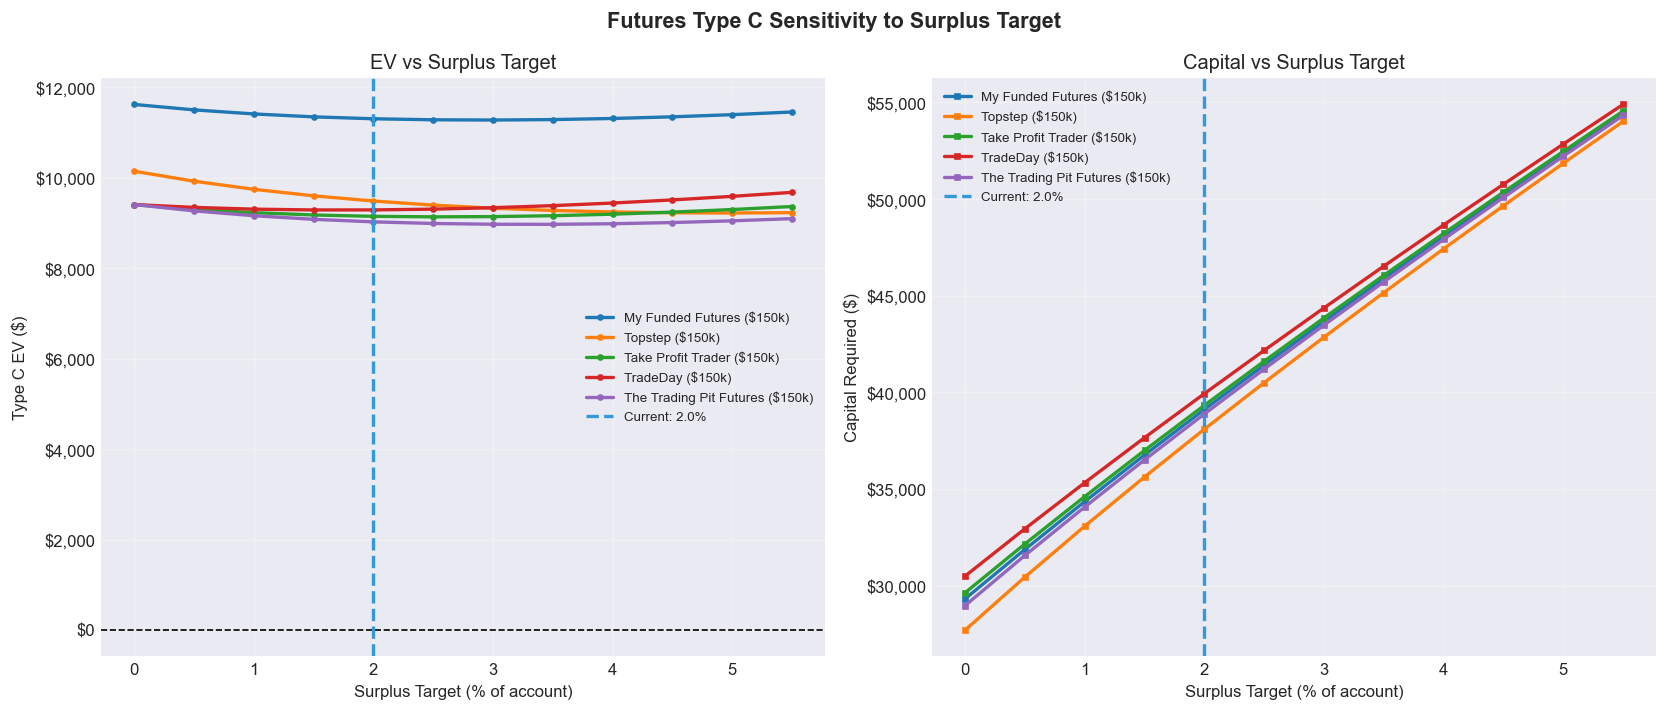

In [8]:
top5 = df_c.nlargest(5, 'ev')[['firm', 'account_size']]
top5_keys = set(zip(top5['firm'], top5['account_size']))
top5_ch = [ch for ch in parsed if (ch['firm'], ch['account_size']) in top5_keys]

surplus_sweep = np.arange(0, 0.06, 0.005)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.tab10.colors

for i, ch in enumerate(top5_ch):
    evs = []; caps = []
    for sp in surplus_sweep:
        r = compute_type_bc_futures(ch, surplus_target_pct=sp)
        evs.append(r['ev'] if r else 0)
        caps.append(r['capital_required'] if r else 0)
    label = f"{ch['firm']} (${ch['account_size']/1000:.0f}k)"
    ax1.plot(surplus_sweep * 100, evs, marker='o', markersize=3,
             label=label, linewidth=2, color=colors[i % 10])
    ax2.plot(surplus_sweep * 100, caps, marker='s', markersize=3,
             label=label, linewidth=2, color=colors[i % 10])

ax1.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax1.axvline(x=SURPLUS_TARGET_PCT * 100, color='#3498db', linewidth=2, linestyle='--',
            label=f'Current: {SURPLUS_TARGET_PCT*100:.1f}%')
ax1.set_xlabel('Surplus Target (% of account)')
ax1.set_ylabel('Type C EV ($)')
ax1.set_title('EV vs Surplus Target')
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(alpha=0.3)

ax2.axvline(x=SURPLUS_TARGET_PCT * 100, color='#3498db', linewidth=2, linestyle='--',
            label=f'Current: {SURPLUS_TARGET_PCT*100:.1f}%')
ax2.set_xlabel('Surplus Target (% of account)')
ax2.set_ylabel('Capital Required ($)')
ax2.set_title('Capital vs Surplus Target')
ax2.legend(fontsize=8)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(alpha=0.3)

plt.suptitle('Futures Type C Sensitivity to Surplus Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7 — All Three Types Summary Table

In [9]:
summary = pd.DataFrame({
    'firm': df_c['firm'],
    'size': df_c['account_size'],
    'dd': df_c['dd_type'],
    'fee': df_c['fee'],
    'act_fee': df_c['activation_fee'],
    'cap': df_c['payout_cap'],
    'EV_A': df_c['type_a_ev'],
    'EV_B': df_b['ev'],
    'EV_C': df_c['ev'],
    'B_vs_A': df_b['ev'] - df_c['type_a_ev'],
    'C_vs_B': df_c['ev'] - df_b['ev'],
    'Cap_B': df_b['capital_required'],
    'Cap_C': df_c['capital_required'],
})

summary.sort_values('EV_C', ascending=False).head(20).style.format({
    'fee': '${:,.0f}', 'act_fee': '${:,.0f}', 'cap': '${:,.0f}',
    'size': '${:,}',
    'EV_A': '${:,.0f}', 'EV_B': '${:,.0f}', 'EV_C': '${:,.0f}',
    'B_vs_A': '${:+,.0f}', 'C_vs_B': '${:+,.0f}',
    'Cap_B': '${:,.0f}', 'Cap_C': '${:,.0f}',
}).bar(subset=['EV_C'], color='#ff9800').bar(
    subset=['EV_B'], color='#2ecc71'
).bar(subset=['EV_A'], color='#1976d2').set_caption(
    'Futures Top 20 — All Three Hedge Types Compared'
)

,firm,size,dd,fee,act_fee,cap,EV_A,EV_B,EV_C,B_vs_A,C_vs_B,Cap_B,Cap_C
42,My Funded Futures,"$150,000.0",trailing,$347,$0,"$100,000","$2,058","$11,621","$11,304","$+9,564",$-317,"$29,314","$39,111"
47,Topstep,"$150,000.0",trailing,$149,$149,"$5,000",$35,"$10,146","$9,486","$+10,111",$-660,"$27,698","$38,092"
52,TradeDay,"$150,000.0",trailing,$300,$139,"$20,000",$372,"$9,408","$9,289","$+9,036",$-118,"$30,492","$39,933"
48,Take Profit Trader,"$150,000.0",trailing,$360,$130,$0,$947,"$9,408","$9,147","$+8,460",$-260,"$29,629","$39,326"
53,The Trading Pit Futures,"$150,000.0",trailing,$289,$129,"$500,050","$1,388","$9,408","$9,025","$+8,020",$-382,"$28,968","$38,882"
26,My Funded Futures,"$100,000.0",trailing,$267,$0,"$100,000","$1,151","$7,747","$7,595","$+6,597",$-153,"$19,874","$26,301"
32,Topstep,"$100,000.0",trailing,$99,$149,"$5,000","$1,642","$7,747","$7,325","$+6,105",$-422,"$18,537","$25,437"
50,AquaFutures,"$150,000.0",trailing,$285,$0,"$4,500",$891,"$8,301","$7,012","$+7,409","$-1,289","$25,663","$37,094"
33,Take Profit Trader,"$100,000.0",trailing,$330,$130,$0,$-488,"$6,272","$6,345","$+6,760",$+73,"$21,433","$27,445"
54,Earn2Trade,"$150,000.0",trailing,$375,$139,"$4,000","$-2,355","$6,456","$6,222","$+8,811",$-234,"$29,782","$39,431"


## 8 — Type C Futures Summary

### What Type C tells you

- The failure event itself becomes a profit centre, not just recovery.
- Hedge is oversized: $S = (L + P) / DD$ — more drag, but failure pays surplus.
- EV_C = funded withdrawals + expected surplus − total drag.
- The surplus target is tuneable — higher surplus = more drag = more capital.

### When to use Type C

- You have enough capital for the larger hedge
- You want to monetise the downside (failure becomes a payoff)
- The challenge has high enough EV_B that the extra drag is affordable

### Tradeoffs vs Type B

| | Type B | Type C |
|---|---|---|
| Failure outcome | Recovers stack (break even) | Recovers stack + surplus |
| Ongoing drag | Lower | Higher |
| Capital | Lower | Higher |
| Best for | Capital-conscious | Traders who want failure to pay |

### Futures-specific considerations

- Payout caps limit withdrawal income but surplus on failure is uncapped
- Trailing DD already inflates the cost stack — Type C amplifies this further
- Larger account sizes have proportionally larger surplus targets

---

**See also:**
- [Type A notebook](type_a_futures_insurance.ipynb) — Challenge-only model
- [Type B notebook](type_b_futures_recovery.ipynb) — Funded recovery model
- [General futures model](futures_hedge_model.ipynb) — All-in-one reference